In [1]:
import sys                                                                                                                                                                                    
sys.path.append('../src')   
from pathlib import Path                                                                                                                                                                      
from dotenv import load_dotenv  

load_dotenv(Path('../.env'))

import pandas as pd                                                                                                                                                                           
import matplotlib.pyplot as plt                                                                                                                                                               
import seaborn as sns                                                                                                                                                                         

from features import fetch_features                                                                                                                                                           
                                                                                                                                                                                                
df = fetch_features(limit=50000)                                                                                                                                                              
                                                                                                                                                                                                
print("shape:", df.shape)                                                                                                                                                                     
                                                                                                                                                                                                
df.head()

/Users/aditya/transit-Analytics/dbt-env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


shape: (50000, 8)


,start_station_id,year,month,day,day_of_week,hour,is_weekend,trip_count
0,72,2013,7,1,2,1,0,1
1,72,2013,7,1,2,5,0,2
2,72,2013,7,1,2,6,0,1
3,72,2013,7,1,2,8,0,9
4,72,2013,7,1,2,9,0,4


In [2]:
df.describe()

,start_station_id,year,month,day,day_of_week,hour,is_weekend,trip_count
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
mean,75.28748,2015.27624,6.87442,15.75826,4.01742,13.41262,0.26744,4.92418
std,3.493577,1.460676,3.116954,8.733095,1.965318,5.724577,0.442628,4.544439
min,72.0,2013.0,1.0,1.0,1.0,0.0,0.0,1.0
25%,72.0,2014.0,4.0,8.0,2.0,9.0,0.0,2.0
50%,72.0,2015.0,7.0,16.0,4.0,14.0,0.0,4.0
75%,79.0,2017.0,9.0,23.0,6.0,18.0,1.0,7.0
max,79.0,2018.0,12.0,31.0,7.0,23.0,1.0,42.0


In [3]:
df.isnull().sum()

start_station_id    0
year                0
month               0
day                 0
day_of_week         0
hour                0
is_weekend          0
trip_count          0
dtype: int64

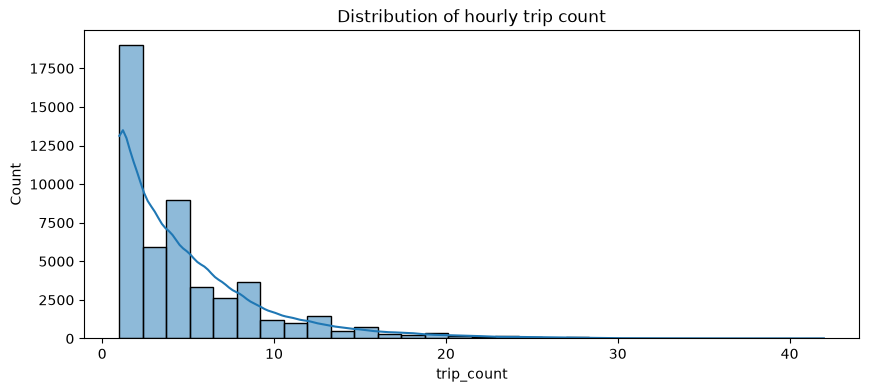

In [4]:
import matplotlib.pyplot as plt   

plt.figure(figsize=(10, 4))

sns.histplot(data=df, x='trip_count', bins=30, kde=True)

plt.title('Distribution of hourly trip count')
plt.xlabel('trip_count')
plt.show()

In [7]:
df.groupby('hour')['trip_count'].mean() 

hour
0     1.638104
1     1.376374
2     1.240481
3     1.215116
4     1.118694
5     1.170601
6     1.897349
7     3.628546
8     7.943249
9     5.883696
10    4.160983
11    4.251759
12    4.867884
13    5.093573
14    5.309668
15    5.477617
16    6.315992
17    7.873191
18    8.875738
19    6.515184
20    4.157831
21    3.021583
22    2.592811
23    2.027778
Name: trip_count, dtype: Float64

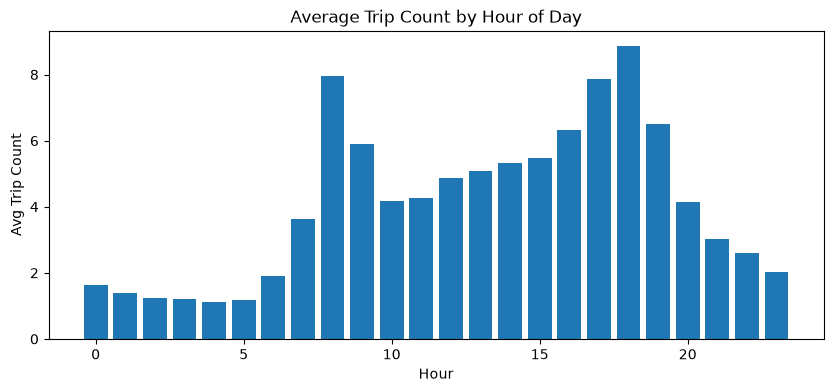

In [8]:
hourly_avg = df.groupby('hour')['trip_count'].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly_avg.index, hourly_avg.values)                                                                                                                                                  
plt.title('Average Trip Count by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Trip Count')                                                                                                                                                                  
plt.show()

In [10]:
df.groupby('day_of_week')['trip_count'].mean()

day_of_week
1    4.397693
2    4.996119
3    5.050841
4    5.281717
5    5.206262
6    5.024955
7    4.416568
Name: trip_count, dtype: Float64

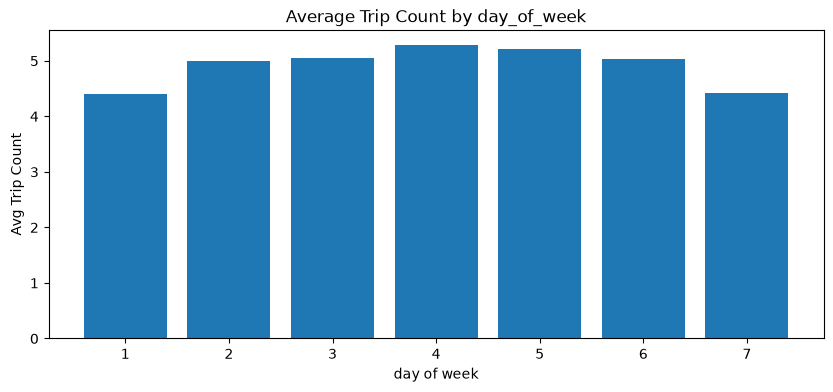

In [13]:
week_day = df.groupby('day_of_week')['trip_count'].mean()

plt.figure(figsize=(10, 4))
plt.bar(week_day.index, week_day.values)                                                                                                                                                  
plt.title('Average Trip Count by day_of_week')
plt.xlabel('day of week')
plt.ylabel('Avg Trip Count')                                                                                                                                                                  
plt.show()7

In [14]:
df.groupby('month')['trip_count'].mean()

month
1      2.53317
2     2.579416
3     3.535452
4     4.847203
5     5.687175
6     5.747461
7     5.841081
8     6.048159
9     5.928394
10    5.491937
11    4.117755
12    3.006688
Name: trip_count, dtype: Float64

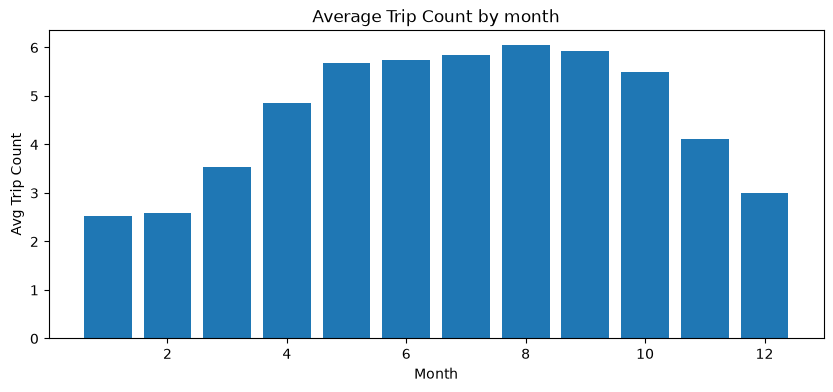

In [16]:
month = df.groupby('month')['trip_count'].mean()

plt.figure(figsize=(10, 4))
plt.bar(month.index, month.values)                                                                                                                                                  
plt.title('Average Trip Count by month')
plt.xlabel('Month')
plt.ylabel('Avg Trip Count')                                                                                                                                                                  
plt.show()